In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [63]:
data = pd.read_csv('../data/sus_ocular_data.csv')
data.head()

,age,year,state,population,glaucoma,retina,eye
0,25,2010,RO,301494,0,0,2
1,25,2010,AC,139508,0,0,13
2,25,2010,AM,671416,-1,1,39
3,25,2010,RR,87860,-1,0,2
4,25,2010,PA,1475525,0,2,60


In [64]:
# -1 are missing values in this dataset
data.replace(-1, np.nan, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         3024 non-null   int64  
 1   year        3024 non-null   int64  
 2   state       3024 non-null   object 
 3   population  3024 non-null   int64  
 4   glaucoma    2800 non-null   float64
 5   retina      3008 non-null   float64
 6   eye         3024 non-null   int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 165.5+ KB


In [65]:
# Build per-million rates by taking population into account
data['glaucoma_rate'] = data['glaucoma'] / data['population'] * 10**6
data['retina_rate'] = data['retina'] / data['population'] * 10**6
data['eye_rate'] = data['eye'] / data['population'] * 10**6

data[['glaucoma_rate', 'retina_rate', 'eye_rate']].describe()

,glaucoma_rate,retina_rate,eye_rate
count,2800.000000,3008.000000,3024.000000
mean,38.033969,210.245483,923.021965
std,72.801761,279.739512,1477.354485
min,0.000000,0.000000,0.000000
25%,0.000000,21.209026,113.588839
50%,6.562183,90.044025,317.849147
75%,40.382734,308.778038,1111.683018
max,642.259825,1982.456195,18256.430141


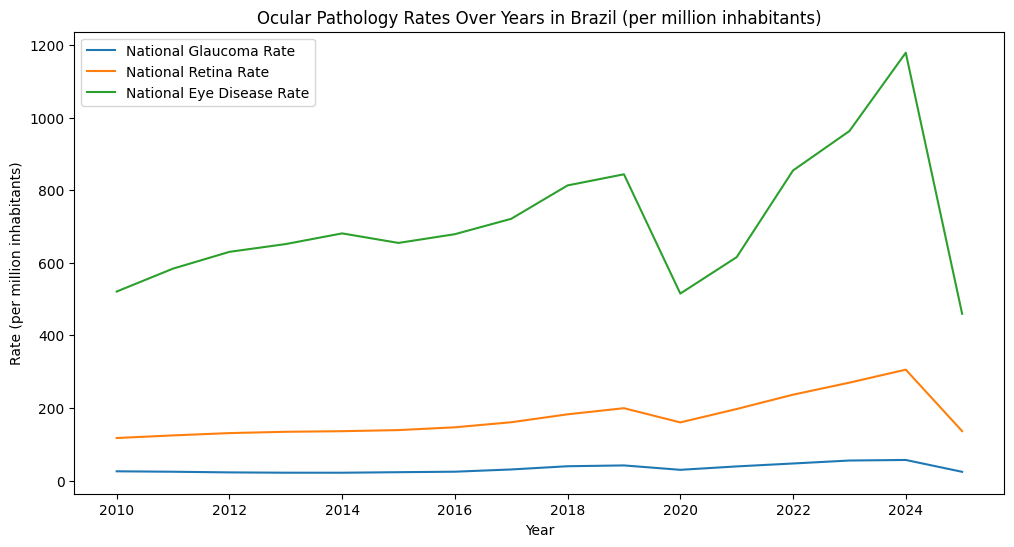

In [66]:
# rates evolution over years
agg = data.groupby('year').agg({
    'glaucoma': 'sum',
    'retina': 'sum',
    'eye': 'sum',
    'population': 'sum'
}).reset_index()

# calcular taxas por milhão
agg['glaucoma_rate'] = agg['glaucoma'] / agg['population'] * 1e6
agg['retina_rate']   = agg['retina']   / agg['population'] * 1e6
agg['eye_rate']      = agg['eye']      / agg['population'] * 1e6


plt.figure(figsize=(12, 6))
sns.lineplot(data=agg, x='year', y='glaucoma_rate', label='National Glaucoma Rate')
sns.lineplot(data=agg, x='year', y='retina_rate', label='National Retina Rate')
sns.lineplot(data=agg, x='year', y='eye_rate', label='National Eye Disease Rate')
plt.title('Ocular Pathology Rates Over Years in Brazil (per million inhabitants)')
plt.xlabel('Year')
plt.ylabel('Rate (per million inhabitants)')
plt.legend()
plt.show()

c:\Users\quiia\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\quiia\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\quiia\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

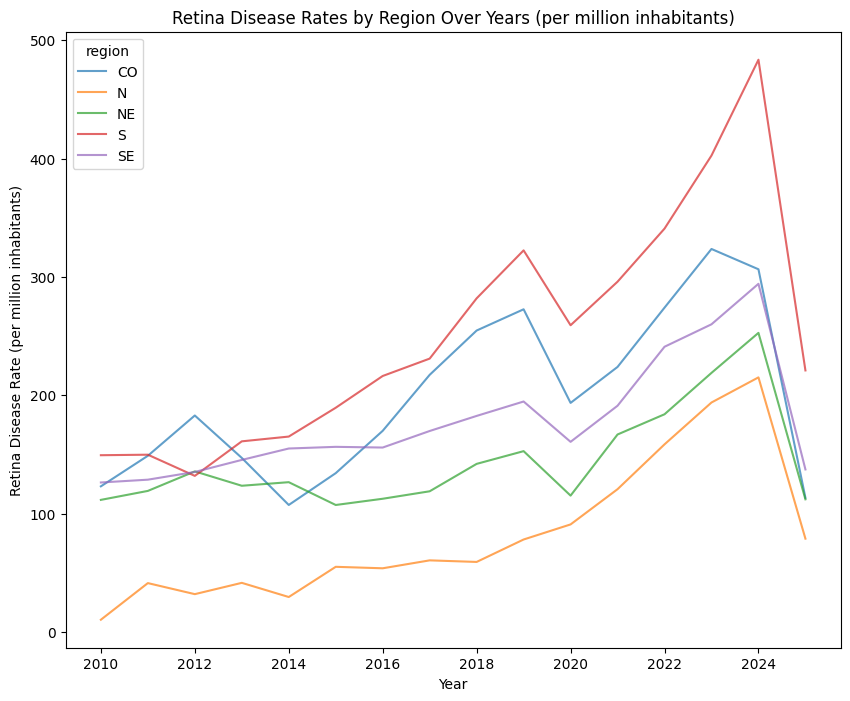

In [67]:
# scatterplot comparing states
data['region'] = data['state'].map({
                                    'AC': 'N',
                                    'AL': 'NE',
                                    'AP': 'N',
                                    'AM': 'N',
                                    'BA': 'NE',
                                    'CE': 'NE',
                                    'DF': 'CO',
                                    'ES': 'SE',
                                    'GO': 'CO',
                                    'MA': 'NE',
                                    'MS': 'CO',
                                    'MT': 'CO',
                                    'MG': 'SE',
                                    'PA': 'N',
                                    'PB': 'NE',
                                    'PR': 'S',
                                    'PE': 'NE',
                                    'PI': 'NE',
                                    'RJ': 'SE',
                                    'RN': 'NE',
                                    'RS': 'S',
                                    'RO': 'N',
                                    'RR': 'N',
                                    'SC': 'S',
                                    'SP': 'SE',
                                    'SE': 'NE',
                                    'TO': 'N'
                                })

agg = data.groupby(['year', 'region']).agg({
    'glaucoma': 'sum',
    'retina': 'sum',
    'eye': 'sum',
    'population': 'sum'
}).reset_index()

# calcular taxas por milhão
agg['glaucoma_rate'] = agg['glaucoma'] / agg['population'] * 1e6
agg['retina_rate']   = agg['retina']   / agg['population'] * 1e6
agg['eye_rate']      = agg['eye']      / agg['population'] * 1e6

plt.figure(figsize=(10, 8))
sns.lineplot(data=agg, x='year', y='retina_rate', hue='region', alpha=0.7)
plt.title('Retina Disease Rates by Region Over Years (per million inhabitants)')
plt.xlabel('Year')
plt.ylabel('Retina Disease Rate (per million inhabitants)')
plt.show()

c:\Users\quiia\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\quiia\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\quiia\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

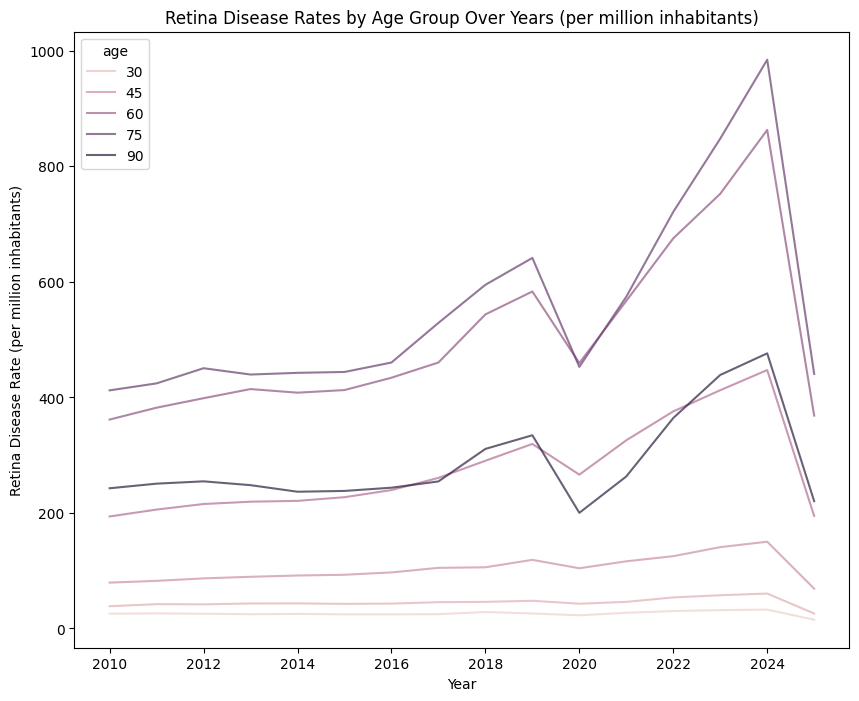

In [82]:
# By age group
agg = data.groupby(['year', 'age']).agg({
    'glaucoma': 'sum',
    'retina': 'sum',
    'eye': 'sum',
    'population': 'sum'
}).reset_index()

# calcular taxas por milhão
agg['glaucoma_rate'] = agg['glaucoma'] / agg['population'] * 1e6
agg['retina_rate']   = agg['retina']   / agg['population'] * 1e6
agg['eye_rate']      = agg['eye']      / agg['population'] * 1e6

plt.figure(figsize=(10, 8))
sns.lineplot(data=agg, x='year', y='retina_rate', hue='age', alpha=0.7)
plt.title('Retina Disease Rates by Age Group Over Years (per million inhabitants)')
plt.xlabel('Year')
plt.ylabel('Retina Disease Rate (per million inhabitants)')
plt.show()

glaucoma_rate 38.03396858275119 72.80176108360861
retina_rate 210.2454826040354 279.7395124652422
eye_rate 923.0219648933656 1477.3544850945589
age 55.714285714285715 21.12027168158083
year 2017.5 4.610534615524831
population 12.738431794107028 1.417170498368206


<Axes: >

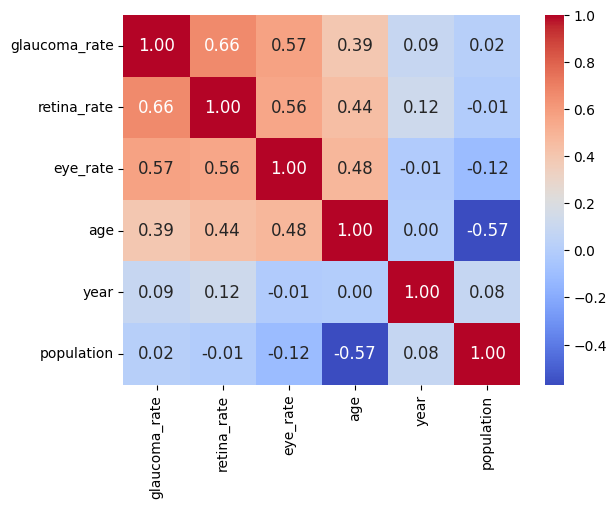

In [80]:
temp = data[['glaucoma_rate', 'retina_rate', 'eye_rate', 'age', 'year', 'population']].copy()

temp['population'] = np.log(temp['population'])

for col in temp.columns:
    print(col, temp[col].mean(), temp[col].std())
    temp[col] = (temp[col] - temp[col].mean()) / temp[col].std()

sns.heatmap(temp.corr(), annot=True, fmt=".2f", cmap='coolwarm', annot_kws={'fontsize':12})